# Sign Language MNIST: aporte de Jenaro al modelo y entrenamiento

Versión derivada del notebook del equipo. Conserva la carga, el EDA y el
preprocesamiento existentes. Jenaro desarrolla las secciones 5 y 6: diseño
de tres MLP, entrenamiento, comparación por validación y justificación.
Al final se ejecuta el bloque de evaluación que ya tenía el proyecto, sobre
el modelo seleccionado. Jason conserva la responsabilidad de interpretar
los errores y redactar las conclusiones globales.

**Pregunta del experimento:** ¿aumentar la cantidad de capas y neuronas
mejora el desempeño de validación lo suficiente como para justificar su costo?

**Referencia principal:** actividades de clases 1.4.3 y 1.4.4. Dataset
confirmado como aprobado por el profesor por Jenaro. Esta ejecución utiliza
las 24 clases disponibles y la partición estratificada de Gonzalo, semilla 42.

**Antes de ejecutar:** instalar las dependencias y preparar los CSV siguiendo
el README. Abrir este notebook desde el repositorio y ejecutar todas las celdas
en orden. El notebook 01 se conserva como versión inicial del equipo.

## 1. Contexto del problema

El problema consiste en clasificar imagenes de letras del lenguaje de senas americano. Cada imagen representa una letra y el modelo debe predecir la clase correcta. Como primera version se usa un Perceptron Multicapa, aunque se espera discutir sus limitaciones frente a imagenes.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from sign_mlp.data import as_images, label_to_letter, load_sign_mnist, prepare_sign_mnist_data
from sign_mlp.evaluate import plot_confusion, plot_history, plot_prediction_examples, report_metrics
from sign_mlp.model import build_mlp

sns.set_theme(style="whitegrid")
PROJECT_ROOT.name


'sign-language-mnist-mlp'

## 2. Carga de datos

Desde la raíz del repositorio ejecutar una vez:

```python
python scripts/prepare_data.py --zip "RUTA/Sign Language MNIST.zip"
```

Se usan `data/raw/sign_mnist_train.csv` y `data/raw/sign_mnist_test.csv`.
El ZIP contiene copias repetidas de esos CSV: el preparador toma una sola
copia de cada uno. El contenido original del ZIP se conserva.

In [2]:
X_train_full, y_train_full, X_test, y_test = load_sign_mnist(PROJECT_ROOT / "data" / "raw")

print("Train:", X_train_full.shape, y_train_full.shape)
print("Test:", X_test.shape, y_test.shape)
print("Pixel min/max:", X_train_full.min(), X_train_full.max())

Train: (27455, 784) (27455,)
Test: (7172, 784) (7172,)
Pixel min/max: 0.0 1.0


## 3. Analisis exploratorio de datos

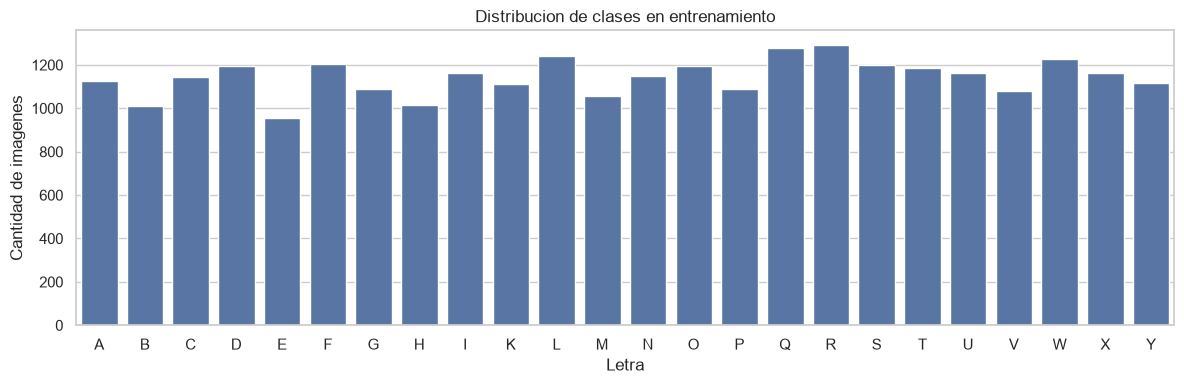

In [3]:
labels_df = pd.DataFrame({"label": y_train_full})
labels_df["letter"] = labels_df["label"].apply(label_to_letter)

plt.figure(figsize=(12, 4))
sns.countplot(data=labels_df, x="letter", order=sorted(labels_df["letter"].unique()))
plt.title("Distribucion de clases en entrenamiento")
plt.xlabel("Letra")
plt.ylabel("Cantidad de imagenes")
plt.tight_layout()
plt.show()

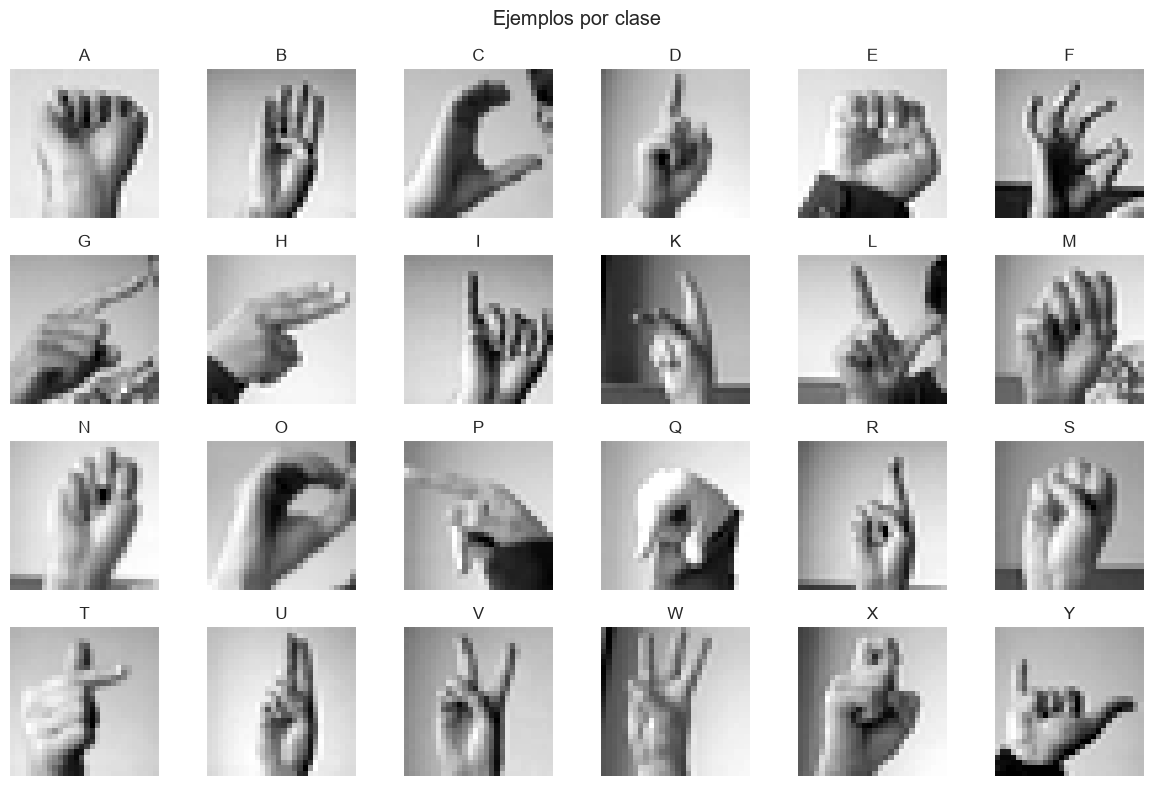

In [4]:
unique_labels = sorted(np.unique(y_train_full))
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
axes = axes.ravel()

for ax, label in zip(axes, unique_labels[:24]):
    idx = np.where(y_train_full == label)[0][0]
    ax.imshow(as_images(X_train_full[[idx]])[0], cmap="gray")
    ax.set_title(label_to_letter(label))
    ax.axis("off")

for ax in axes[len(unique_labels[:24]):]:
    ax.axis("off")

plt.suptitle("Ejemplos por clase")
plt.tight_layout()
plt.show()

## 4. Preprocesamiento

Las imagenes ya vienen como vectores de 784 pixeles. Cada pixel se normalizo dividiendo por 255, por lo que los valores quedan entre 0 y 1. Ademas, se crea una particion de validacion desde el set de entrenamiento.

In [5]:
RANDOM_STATE = 42

prepared = prepare_sign_mnist_data(
    PROJECT_ROOT / "data" / "raw",
    validation_size=0.2,
    random_state=RANDOM_STATE,
)

X_train_full = prepared["X_train_full"]
y_train_full = prepared["y_train_full"]
X_train = prepared["X_train"]
X_val = prepared["X_val"]
X_test = prepared["X_test"]
y_train = prepared["y_train"]
y_val = prepared["y_val"]
y_test_idx = prepared["y_test"]
label_to_index = prepared["label_to_index"]
index_to_label = prepared["index_to_label"]

num_classes = len(index_to_label)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Classes:", num_classes)
print("Input MLP:", prepared["metadata"]["input_dim"])

Train: (21964, 784)
Validation: (5491, 784)
Test: (7172, 784)
Classes: 24
Input MLP: 784


## 5. Diseño del MLP — Jenaro

### 5.1 Relación con las clases

Una capa densa calcula `Z = X @ W + b` y aplica una activación, como en la
actividad de redes feedforward. Keras implementa esas operaciones con
`Sequential` y `Dense`. Durante el entrenamiento, backpropagation calcula
gradientes y el optimizador actualiza pesos y sesgos para reducir la pérdida.

| Decisión | Elección y fundamento |
| --- | --- |
| Entrada | 784 píxeles normalizados. Los CSV ya están aplanados; no hace falta añadir `Flatten`. |
| Capas ocultas | Comparar tres capacidades de la actividad 1.4.4. Son hipótesis de trabajo, no una arquitectura óptima conocida. |
| Activación oculta | ReLU: `max(0, z)`, introduce no linealidad y permite modelar relaciones entre píxeles. |
| Salida | 24 neuronas con softmax: una distribución sobre las letras presentes. Se predice el índice de mayor valor. |
| Etiquetas y pérdida | One-hot y `categorical_crossentropy`, como en el ejemplo MNIST de clases. |
| Optimizador | Adam, usado en 1.4.3 y 1.4.4. Ajusta los pesos a partir de los gradientes. |
| Learning rate | 0,001 como punto inicial de clase. Se mantiene fijo para comparar capacidades. |
| Épocas | 20 para cada modelo: mismo número de recorridos completos por los datos. |
| Batch | 128 ejemplos por actualización, salvo el último lote incompleto. |
| Regularización | Solo capas densas: `dropout=0`. Así la primera comparación se centra en capacidad. |

La configuración previa del repositorio `(256, 128)` con Dropout era un
punto inicial sin resultados guardados. En esta versión se sustituye por
el experimento de tres capacidades de la actividad, sin cambiar el
preprocesamiento. No se usan CNN, aumento de datos ni búsquedas automáticas.

### 5.2 Experimento y criterio de selección, definidos antes de entrenar

- **A, pequeña `(32,)`:** línea base de bajo costo; podría tener capacidad insuficiente.
- **B, mediana `(128, 64)`:** mayor capacidad; podría mejorar la representación de las imágenes.
- **C, grande `(512, 256, 128)`:** mayor capacidad y costo; podría mejorar o sobreajustar.

Todas usan el mismo train/validation, semilla, optimizador, batch y número
de épocas. Se comparan los pesos de la **última época** de cada modelo.
El criterio principal es **F1 macro de validación**: cada letra pesa igual.
En un empate exacto se prefiere menor pérdida de validación y después menor
número de parámetros. El test oficial se reserva hasta seleccionar el modelo.

Se fija una semilla para repetir el experimento. La comparación corresponde
a una corrida por arquitectura; no demuestra superioridad estadística y
puede variar al cambiar semilla, versiones o hardware.

In [6]:
import hashlib
import json
import platform
import os
from importlib.metadata import version
from time import perf_counter

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import Markdown, display

SEED = 42
EPOCHS = 20
BATCH_SIZE = 128
LEARNING_RATE = 0.001
ARCHITECTURES = {
    "A_pequena": (32,),
    "B_mediana": (128, 64),
    "C_grande": (512, 256, 128),
}

tf.keras.utils.set_random_seed(SEED)
for directory in ("images", "reports", "models"):
    (PROJECT_ROOT / directory).mkdir(exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Train / validación / test:", len(X_train), len(X_val), len(X_test))
print("Clases:", prepared["metadata"]["class_names"])

TensorFlow: 2.20.0
Train / validación / test: 21964 5491 7172
Clases: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


### 5.3 One-hot encoding de las etiquetas

Los índices preparados por Gonzalo son consecutivos de 0 a 23. `to_categorical`
transforma cada índice en un vector de 24 posiciones: un 1 para la clase
correcta y ceros para las restantes. Cada fila de `y_train_cat` suma 1.

Esta transformación es solo para la función de pérdida; se conservan los
índices enteros para calcular métricas y las etiquetas originales para
mostrar las letras. El remapeo es necesario porque las etiquetas del CSV
saltan de 8 a 10: no se debe interpretar directamente el índice 9 como J.

In [7]:
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)

assert X_train.shape[1] == 784 and num_classes == 24
assert y_train_cat.shape == (len(X_train), num_classes)
assert np.allclose(y_train_cat.sum(axis=1), 1)
assert np.array_equal(np.argmax(y_train_cat, axis=1), y_train)
assert set(np.unique(y_train)) == set(range(num_classes))
assert np.isfinite(X_train).all() and 0 <= X_train.min() <= X_train.max() <= 1

print("Índice:", y_train[0], "Letra:", label_to_letter(index_to_label[int(y_train[0])]))
print("One-hot:", y_train_cat[0])

Índice: 2 Letra: C
One-hot: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 5.4 Construcción y cantidad de parámetros

`build_mlp` está en `src/sign_mlp/model.py`. Agrega una capa `Dense` por
cada tamaño indicado y una salida softmax. Se solicita explícitamente
`loss="categorical_crossentropy"` porque ahora usamos one-hot.

En una capa densa con `d` entradas y `n` neuronas hay `d*n` pesos y `n`
sesgos: **`(d + 1) * n` parámetros**. Esta cuenta permite explicar el costo
de aumentar la capacidad sin asumir que una red más grande será mejor.

In [8]:
def count_dense_parameters(hidden_layers):
    dimensions = (X_train.shape[1], *hidden_layers, num_classes)
    return sum((inputs + 1) * outputs for inputs, outputs in zip(dimensions, dimensions[1:]))

architecture_table = pd.DataFrame([
    {"Modelo": name, "Capas ocultas": str(layers), "Parámetros": count_dense_parameters(layers)}
    for name, layers in ARCHITECTURES.items()
])
display(architecture_table)

base_model = build_mlp(
    input_dim=X_train.shape[1], num_classes=num_classes,
    hidden_layers=ARCHITECTURES["A_pequena"], dropout=0,
    learning_rate=LEARNING_RATE, loss="categorical_crossentropy",
)
assert base_model.count_params() == count_dense_parameters(ARCHITECTURES["A_pequena"])
base_model.summary()
del base_model

,Modelo,Capas ocultas,Parámetros
0,A_pequena,"(32,)",25912
1,B_mediana,"(128, 64)",110296
2,C_grande,"(512, 256, 128)",569240


Model: "sign_language_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,912 (101.22 KB)

 Trainable params: 25,912 (101.22 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento y comparación — Jenaro

### 6.1 Entrenar las tres configuraciones

El siguiente ciclo sigue el ejemplo 1.4.3: construir, compilar, entrenar,
predecir y registrar resultados. Se reinicia el estado de Keras y la
semilla antes de construir cada modelo. Ninguna arquitectura reutiliza
los pesos aprendidos por otra.

`fit` recibe la validación explícita ya preparada. Una época recorre
todos los ejemplos de entrenamiento. Con batch 128, hay
`ceil(21964 / 128) = 172` actualizaciones por época, 3.440 en 20 épocas.
Adam utiliza el gradiente de la pérdida, no la accuracy, para actualizar pesos.

Para calcular la brecha train/validación se evalúan ambos conjuntos con
los **pesos finales**. La accuracy que registra `fit` promedia predicciones
hechas mientras los pesos cambian durante la época; no es exactamente
la misma medición que evaluar el modelo al terminar.

In [9]:
models = {}
histories = {}
results = []

for name, hidden_layers in ARCHITECTURES.items():
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    candidate = build_mlp(
        input_dim=X_train.shape[1], num_classes=num_classes,
        hidden_layers=hidden_layers, dropout=0,
        learning_rate=LEARNING_RATE, loss="categorical_crossentropy",
    )
    start = perf_counter()
    candidate_history = candidate.fit(
        X_train, y_train_cat, validation_data=(X_val, y_val_cat),
        epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=0,
    )
    seconds = perf_counter() - start
    train_loss, train_accuracy = candidate.evaluate(X_train, y_train_cat, verbose=0)
    val_loss, val_accuracy = candidate.evaluate(X_val, y_val_cat, verbose=0)
    val_prediction = np.argmax(candidate.predict(X_val, verbose=0), axis=1)
    results.append({
        "modelo": name, "capas": str(hidden_layers),
        "parametros": candidate.count_params(), "epocas": EPOCHS,
        "segundos_fit": seconds, "train_loss": train_loss, "val_loss": val_loss,
        "train_accuracy": train_accuracy, "val_accuracy": val_accuracy,
        "val_precision_macro": precision_score(y_val, val_prediction, average="macro", zero_division=0),
        "val_recall_macro": recall_score(y_val, val_prediction, average="macro", zero_division=0),
        "val_f1_macro": f1_score(y_val, val_prediction, average="macro", zero_division=0),
        "gap_accuracy": train_accuracy - val_accuracy,
    })
    models[name] = candidate
    histories[name] = candidate_history
    history_frame = pd.DataFrame(candidate_history.history)
    history_frame.index = np.arange(1, len(history_frame) + 1)
    history_frame.index.name = "epoca"
    history_frame.to_csv(PROJECT_ROOT / "reports" / f"jenaro_historial_{name}.csv")
    print(f"{name}: F1 macro validación={results[-1]['val_f1_macro']:.4f}, tiempo={seconds:.1f} s")

A_pequena: F1 macro validación=0.6556, tiempo=6.1 s


B_mediana: F1 macro validación=0.9790, tiempo=8.5 s


C_grande: F1 macro validación=1.0000, tiempo=18.3 s


### 6.2 Comparación con validación

Precision, recall y F1 se calculan por clase y se promedian sin ponderar
por frecuencia (`macro`). La accuracy cuenta aciertos sobre el total.
La pérdida considera también las probabilidades: dos modelos pueden
tener accuracy parecida y distinta crossentropy.

Los tiempos miden solo `fit` en este equipo. La tabla permite comparar
capacidad, desempeño y costo. Aún no se ha evaluado el test.

In [10]:
comparison = pd.DataFrame(results).sort_values(
    ["val_f1_macro", "val_loss", "parametros"], ascending=[False, True, True],
).reset_index(drop=True)
best_name = comparison.loc[0, "modelo"]
model = models[best_name]
history = histories[best_name]

comparison.to_csv(PROJECT_ROOT / "reports" / "jenaro_comparacion_validacion.csv", index=False)
display(comparison.round(5))
print("Modelo elegido por validación:", best_name)

,modelo,capas,parametros,epocas,segundos_fit,train_loss,val_loss,train_accuracy,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,gap_accuracy
0,C_grande,"(512, 256, 128)",569240,20,18.31783,0.00206,0.00260,1.00000,1.00000,1.00000,1.00000,1.00000,0.00000
1,B_mediana,"(128, 64)",110296,20,8.53348,0.10400,0.11781,0.98338,0.97796,0.98155,0.97819,0.97903,0.00542
2,A_pequena,"(32,)",25912,20,6.07835,1.05565,1.07478,0.67351,0.65598,0.66254,0.65838,0.65555,0.01753


Modelo elegido por validación: C_grande


### 6.3 Curvas de aprendizaje

La línea de entrenamiento muestra cómo cambia la pérdida o la accuracy
durante `fit`; la de validación se calcula al terminar cada época.
Si train loss baja mientras val loss aumenta de forma sostenida, aparece
una señal de sobreajuste. Un pico aislado no basta para concluirlo.
Si ambas pérdidas se mantienen altas y mejoran poco, puede faltar
aprendizaje o capacidad. La interpretación debe considerar la trayectoria.

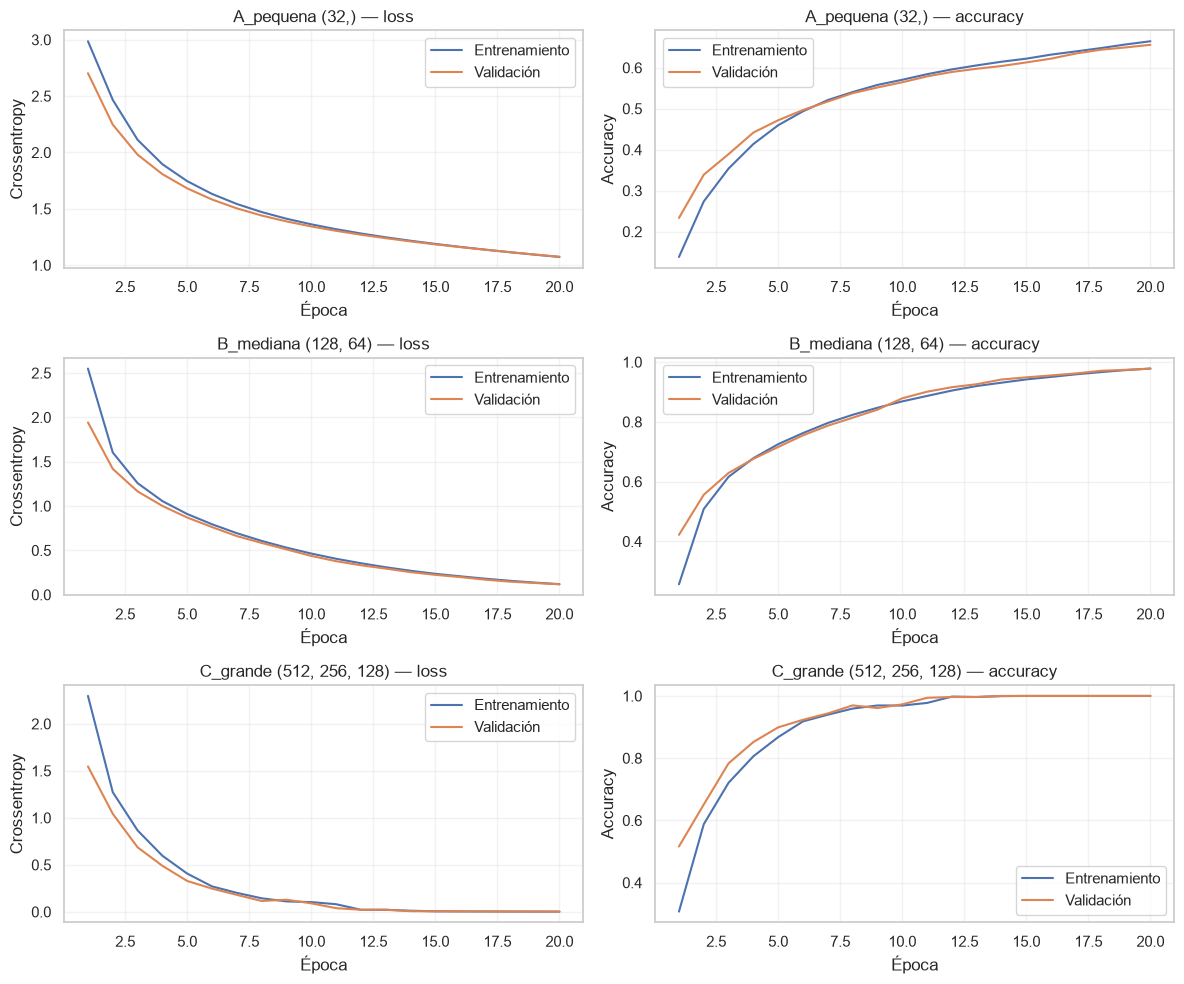

In [11]:
fig, axes = plt.subplots(len(ARCHITECTURES), 2, figsize=(12, 10))
for row, (name, item_history) in enumerate(histories.items()):
    epochs_axis = np.arange(1, len(item_history.history["loss"]) + 1)
    for col, metric in enumerate(("loss", "accuracy")):
        ax = axes[row, col]
        ax.plot(epochs_axis, item_history.history[metric], label="Entrenamiento")
        ax.plot(epochs_axis, item_history.history["val_" + metric], label="Validación")
        ax.set_title(f"{name} {ARCHITECTURES[name]} — {metric}")
        ax.set_xlabel("Época")
        ax.set_ylabel("Crossentropy" if metric == "loss" else "Accuracy")
        ax.legend()
        ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "images" / "jenaro_curvas_comparacion.png", dpi=150)
plt.show()

In [12]:
best = comparison.iloc[0]
learning_notes = []
for _, result in comparison.iterrows():
    values = histories[result["modelo"]].history
    note = (
        f"**{result['modelo']}**: la pérdida de entrenamiento pasó de "
        f"{values['loss'][0]:.4f} a {values['loss'][-1]:.4f} y la de validación "
        f"de {values['val_loss'][0]:.4f} a {values['val_loss'][-1]:.4f}. "
        f"El mínimo de validación fue {min(values['val_loss']):.4f} en la época "
        f"{int(np.argmin(values['val_loss'])) + 1}. Con los pesos finales, "
        f"la diferencia train menos validación fue {100 * result['gap_accuracy']:.2f} puntos porcentuales."
    )
    learning_notes.append(note)

selection_text = (
    f"Se selecciona **{best_name}**, capas {ARCHITECTURES[best_name]}, con "
    f"{int(best['parametros']):,} parámetros. Su F1 macro de validación es "
    f"**{best['val_f1_macro']:.4f}** y su accuracy de validación es "
    f"**{100 * best['val_accuracy']:.2f}%**. Esta elección aplica el criterio "
    "fijado antes de entrenar. No usa resultados de test ni implica que sea "
    "la arquitectura óptima para cualquier semilla o conjunto de imágenes."
)
display(Markdown("### Lectura de esta ejecución\n\n" + "\n\n".join(learning_notes) + "\n\n" + selection_text))

### Lectura de esta ejecución

**C_grande**: la pérdida de entrenamiento pasó de 2.2967 a 0.0022 y la de validación de 1.5473 a 0.0026. El mínimo de validación fue 0.0026 en la época 20. Con los pesos finales, la diferencia train menos validación fue 0.00 puntos porcentuales.

**B_mediana**: la pérdida de entrenamiento pasó de 2.5494 a 0.1193 y la de validación de 1.9428 a 0.1178. El mínimo de validación fue 0.1178 en la época 20. Con los pesos finales, la diferencia train menos validación fue 0.54 puntos porcentuales.

**A_pequena**: la pérdida de entrenamiento pasó de 2.9865 a 1.0730 y la de validación de 2.7030 a 1.0748. El mínimo de validación fue 1.0748 en la época 20. Con los pesos finales, la diferencia train menos validación fue 1.75 puntos porcentuales.

Se selecciona **C_grande**, capas (512, 256, 128), con 569,240 parámetros. Su F1 macro de validación es **1.0000** y su accuracy de validación es **100.00%**. Esta elección aplica el criterio fijado antes de entrenar. No usa resultados de test ni implica que sea la arquitectura óptima para cualquier semilla o conjunto de imágenes.

### 6.4 Guardado y entrega del modelo seleccionado

Se guarda el modelo **antes de consultar el test**, junto con el mapeo de
clases, hiperparámetros y versiones. Jason puede cargarlo con
`tf.keras.models.load_model("models/jenaro_mlp.keras")` y convertir el
índice predicho a letra mediante `class_names` de los metadatos.

El modelo espera vectores de 784 píxeles normalizados entre 0 y 1.
Para `evaluate`, la pérdida compilada espera etiquetas one-hot.
Para `predict`, solo se necesitan los píxeles; se aplica `argmax` a las
24 probabilidades. La comprobación de recarga utiliza validación.

In [13]:
model_path = PROJECT_ROOT / "models" / "jenaro_mlp.keras"
model.save(model_path)

reloaded_model = tf.keras.models.load_model(model_path)
expected_proba = model.predict(X_val[:128], verbose=0)
loaded_proba = reloaded_model.predict(X_val[:128], verbose=0)
np.testing.assert_allclose(expected_proba, loaded_proba, rtol=1e-6, atol=1e-7)
assert loaded_proba.shape == (min(128, len(X_val)), num_classes)
assert np.allclose(loaded_proba.sum(axis=1), 1, atol=1e-5)
del reloaded_model

metadata = {
    "responsable": "Jenaro", "seleccionado": best_name,
    "criterio": "F1 macro validación descendente; val_loss ascendente; parámetros ascendentes",
    "pesos_evaluados": "última época de cada arquitectura",
    "test_usado_para_seleccion": False,
    "semilla_particion": RANDOM_STATE, "semilla_entrenamiento": SEED,
    "epochs": EPOCHS, "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
    "activation": "relu", "output_activation": "softmax", "dropout": 0,
    "loss": "categorical_crossentropy", "optimizer": "Adam",
    "arquitecturas": {key: list(value) for key, value in ARCHITECTURES.items()},
    "datos": prepared["metadata"],
    "particiones": {"train": len(X_train), "validation": len(X_val), "test": len(X_test)},
    "resultados_validacion": comparison.to_dict(orient="records"),
    "modelo": "models/jenaro_mlp.keras",
    "modelo_sha256": hashlib.sha256(model_path.read_bytes()).hexdigest(),
    "dataset_sha256": {
        name: hashlib.sha256((PROJECT_ROOT / "data" / "raw" / name).read_bytes()).hexdigest()
        for name in ("sign_mnist_train.csv", "sign_mnist_test.csv")
    },
    "python": platform.python_version(),
    "plataforma": platform.system(),
    "recursos_ejecucion": {name: os.environ.get(name, "valor predeterminado") for name in (
        "TF_NUM_INTRAOP_THREADS", "TF_NUM_INTEROP_THREADS", "OMP_NUM_THREADS",
    )},
    "versiones": {name: version(name) for name in (
        "tensorflow", "keras", "numpy", "pandas", "matplotlib", "seaborn", "scikit-learn",
    )},
    "recarga_verificada": True,
}
(PROJECT_ROOT / "reports" / "jenaro_entrenamiento.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8",
)

table_lines = [
    "| Modelo | Capas | Parámetros | Accuracy train | Accuracy val | F1 macro val | Loss val | Segundos fit |",
    "| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: |",
]
for _, row in comparison.iterrows():
    table_lines.append(
        f"| {row['modelo']} | {row['capas']} | {int(row['parametros'])} | "
        f"{row['train_accuracy']:.4f} | {row['val_accuracy']:.4f} | "
        f"{row['val_f1_macro']:.4f} | {row['val_loss']:.4f} | {row['segundos_fit']:.1f} |"
    )
report = "\n\n".join([
    "# Aporte de Jenaro: modelo y entrenamiento MLP",
    "## Diseño y protocolo",
    "Referencia: actividades 1.4.3 y 1.4.4 de clases. Tres capacidades con capas Dense/ReLU y 24 salidas softmax. "
    "Entrada: 784 píxeles divididos por 255. Etiquetas remapeadas y one-hot. "
    "Pérdida categorical_crossentropy, Adam, learning rate 0,001, batch 128, 20 épocas, sin Dropout. "
    "Semillas de partición y entrenamiento: 42. Train: 21.964; validación: 5.491; test oficial reservado: 7.172.",
    "Se compara el modelo de la última época. Selección por F1 macro de validación; "
    "en empate exacto, menor loss de validación y menor número de parámetros. "
    "Solo una corrida por arquitectura. La interpretación de diferencias pequeñas necesita cautela.",
    "## Comparación de validación", "\n".join(table_lines),
    "## Lectura de curvas", *learning_notes,
    "### Interpretación de la corrida de referencia",
    "Con el protocolo registrado, A mantiene pérdidas mayores y ambas curvas aún descienden al terminar: "
    "muestra aprendizaje insuficiente con este presupuesto, compatible con subajuste, "
    "pero no permite separar por sí solo falta de capacidad de falta de épocas. "
    "B reduce mucho más ambas pérdidas y C se aproxima a cero. En las curvas de esta corrida "
    "no aparece una subida sostenida de val_loss mientras train_loss baja. "
    "Eso no demuestra ausencia de problemas de generalización fuera de la validación interna. "
    "Si se cambian los parámetros o se obtienen otras curvas, debe revisarse esta interpretación.",
    f"C tiene {count_dense_parameters(ARCHITECTURES['C_grande']) / count_dense_parameters(ARCHITECTURES['B_mediana']):.2f} "
    "veces los parámetros de B. La comparación debe considerar ese costo además del beneficio en validación; "
    "el criterio acordado en este experimento prioriza F1 macro, no latencia ni tamaño del modelo.",
    "![Curvas de entrenamiento y validación](../images/jenaro_curvas_comparacion.png)",
    "## Selección", selection_text,
    "## Límites y entrega a Jason",
    "Aplanar conserva los valores de los píxeles, pero las capas densas no usan filtros de vecindad espacial. "
    "El resultado de validación no demuestra desempeño en personas nuevas, fondos nuevos o señas en movimiento. "
    "El test se consulta solo después de elegir el modelo. El análisis de errores y las conclusiones del equipo corresponden a Jason.",
    "Modelo local: `models/jenaro_mlp.keras`. Mapeo, versiones y huellas: `jenaro_entrenamiento.json`. "
    "Recarga del modelo comprobada sobre 128 imágenes de validación. "
    "El modelo y los CSV no se versionan; pueden regenerarse ejecutando el notebook.",
    "## Reproducción y fuentes",
    "Ejecutar desde cero `notebooks/02_sign_language_mnist_mlp_jenaro.ipynb` con los CSV en `data/raw/`. "
    "Ver README y `requirements-jenaro.txt` para el entorno probado. "
    "Los historiales por época y la tabla CSV se exportan en `reports/`.",
    "Material docente: `1.4.4_Notebook_Modelo_Keras_Metricas_Estudiante.ipynb` "
    "(one-hot, arquitecturas, curvas); `1.4.3_Diseño_Evaluacion_Modelos_Fully_Connected_Estudiante.ipynb` "
    "(Keras, optimizadores, comparación); perceptrón, redes fully connected y descenso del gradiente "
    "(fundamentos). Los originales no se modifican. "
    "Resultados calculados mediante la ejecución local; "
    "Jenaro debe revisar y poder explicar las decisiones en la defensa.",
])
(PROJECT_ROOT / "reports" / "jenaro_modelo_entrenamiento.md").write_text(report + "\n", encoding="utf-8")
print("Modelo guardado y recarga verificada. Informe y metadatos exportados.")

Modelo guardado y recarga verificada. Informe y metadatos exportados.


### 6.5 Interpretación del alcance del aporte

**Lectura de la corrida de referencia registrada:** A mantiene pérdidas
mayores y ambas curvas siguen bajando al terminar. Hay aprendizaje
insuficiente con este presupuesto, compatible con subajuste; no se puede
atribuir solamente a la capacidad sin estudiar también las épocas.
B reduce mucho más ambas pérdidas y C se aproxima a cero. No aparece una
subida sostenida de val_loss acompañada de una caída de train_loss en
estas curvas. Eso no demuestra que el modelo generalice igual de bien
fuera de la validación interna.

C tiene aproximadamente 5,16 veces los parámetros de B. El criterio de
este experimento prioriza F1 macro de validación; si la prioridad fuera
reducir memoria o tiempo, habría que establecer otro criterio antes de
comparar. Una única corrida no demuestra una mejora para cualquier contexto.
Si se cambian parámetros o se obtienen otras curvas, revisar esta interpretación.

El alcance es clasificar imágenes de letras ASL presentes en el dataset.
No equivale a reconocer conversaciones completas en lengua de señas ni
a validar un sistema de accesibilidad en condiciones reales.

**Fuentes de clases:** 1.4.4 (MNIST, one-hot, arquitecturas y métricas),
1.4.3 (Keras y experimentos), redes fully connected (capas y softmax),
perceptrón (pesos, sesgos y activaciones), descenso del gradiente (aprendizaje).
Las métricas se calculan al ejecutar. La defensa debe fundamentar las decisiones con los resultados obtenidos.

### 6.6 Opinión fundamentada sobre el modelo

El propósito de esta evaluación es comprender el caso y explicar las
decisiones. Los tres resultados aportan al aprendizaje: permiten discutir
capacidad, pérdida, costo y generalización. No se necesita alcanzar una
cifra objetivo para que el experimento sea informativo.

| Evidencia de esta corrida | Opinión que permite fundamentar | Límite de la conclusión |
| --- | --- | --- |
| A tiene pérdidas más altas y sigue mejorando al terminar. | Su aprendizaje resulta insuficiente con este presupuesto. | No distingue por sí solo falta de capacidad de falta de épocas. |
| B alcanza 97,80% de accuracy de validación con menos parámetros que C. | Ofrece una alternativa de menor tamaño para discutir el costo de aumentar capacidad. | No se evaluó B en test; no podemos afirmar que generalice mejor que C. |
| C obtiene 100% en validación y 79,17% en test. | La validación interna fue optimista y el desempeño no se mantiene igual en el test oficial. | La diferencia no prueba por sí sola qué factor causó los errores. |

**¿Es bueno para nuestro caso?** Como ejercicio y primera aproximación, es
útil: aprende a clasificar imágenes y permite entender un flujo completo.
Como demostración educativa supervisada, podría servir para revisar aciertos
y errores. Para decidir automáticamente si una persona hace bien una seña,
la evidencia es insuficiente: el modelo falla aproximadamente en una de cada
cinco imágenes del test y no se ha validado en ese contexto de uso.

Por eso la valoración depende del objetivo y del costo de equivocarse.
Falta acordar qué nivel y tipo de error serían aceptables para una aplicación
real. No basta etiquetar al modelo como bueno o malo por su accuracy.

La semejanza entre imágenes de entrenamiento y validación, diferencias entre
conjuntos o sobreajuste son posibles líneas de investigación. Se presentan
como hipótesis, sin afirmar causas no comprobadas. La discusión detallada
de letras y ejemplos se integra con el análisis de Jason.


## 7. Evaluación final: bloque existente para integrar con Jason

Se mantiene el código de evaluación del proyecto sobre el modelo elegido
en la sección anterior. Esta es la primera evaluación de test de esta
corrida; no se utilizará para volver a elegir arquitectura. La conversión
a one-hot permite evaluar la pérdida del modelo entrenado por Jenaro.
Las métricas y figuras automáticas son insumos para la interpretación de Jason.

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, to_categorical(y_test_idx, num_classes), verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

y_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

metrics_text = report_metrics(y_test_idx, y_pred, index_to_label)
print(metrics_text)

(PROJECT_ROOT / "reports" / "jenaro_integracion_classification_report.txt").write_text(metrics_text, encoding="utf-8")

test_summary = {
    "modelo": best_name, "seleccion_realizada_antes_del_test": True,
    "test_loss": float(test_loss), "test_accuracy": float(test_accuracy),
    "test_precision_macro": float(precision_score(y_test_idx, y_pred, average="macro", zero_division=0)),
    "test_recall_macro": float(recall_score(y_test_idx, y_pred, average="macro", zero_division=0)),
    "test_f1_macro": float(f1_score(y_test_idx, y_pred, average="macro", zero_division=0)),
    "gap_validacion_test_pp": float(100 * (best["val_accuracy"] - test_accuracy)),
    "n_test": len(y_test_idx),
}
(PROJECT_ROOT / "reports" / "jenaro_integracion_test.json").write_text(
    json.dumps(test_summary, ensure_ascii=False, indent=2), encoding="utf-8",
)
test_note = (
    f"El modelo seleccionado obtiene **{100 * test_accuracy:.2f}% de accuracy en test** "
    f"y **{test_summary['test_f1_macro']:.4f} de F1 macro**, frente a "
    f"{100 * best['val_accuracy']:.2f}% de accuracy en validación. La diferencia "
    f"validación menos test es de **{test_summary['gap_validacion_test_pp']:.2f} puntos porcentuales**. "
    "Esta comparación permite valorar cuánto se mantiene el desempeño al pasar al test oficial. "
    "En la corrida de referencia, la caída muestra que la validación interna ofrece una estimación "
    "optimista del desempeño en ese test. No se puede atribuir la causa solo a sobreajuste, "
    "personas distintas o fondos distintos sin investigar los datos. "
    "Se conserva la selección previa y no se vuelve a ajustar usando este test. "
    "El análisis detallado de clases y ejemplos queda para Jason."
)
display(Markdown("### Generalización del modelo seleccionado\n\n" + test_note))
with (PROJECT_ROOT / "reports" / "jenaro_modelo_entrenamiento.md").open("a", encoding="utf-8") as report_file:
    report_file.write("\n## Comprobación posterior en el test oficial\n\n" + test_note + "\n")

Test loss: 1.1015
Test accuracy: 0.7917


              precision    recall  f1-score   support

           A       0.88      1.00      0.94       331
           B       0.96      0.95      0.95       432
           C       0.81      0.93      0.87       310
           D       0.83      0.82      0.82       245
           E       0.87      1.00      0.93       498
           F       0.72      0.86      0.78       247
           G       0.93      0.77      0.84       348
           H       0.82      0.94      0.87       436
           I       0.81      0.77      0.79       288
           K       0.74      0.55      0.63       331
           L       0.71      0.89      0.79       209
           M       0.81      0.75      0.78       394
           N       0.67      0.56      0.61       291
           O       0.88      0.66      0.75       246
           P       0.99      0.91      0.95       347
           Q       0.73      0.95      0.82       164
           R       0.57      0.72      0.63       144
           S       0.67    

### Generalización del modelo seleccionado

El modelo seleccionado obtiene **79.17% de accuracy en test** y **0.7703 de F1 macro**, frente a 100.00% de accuracy en validación. La diferencia validación menos test es de **20.83 puntos porcentuales**. Esta comparación permite valorar cuánto se mantiene el desempeño al pasar al test oficial. En la corrida de referencia, la caída muestra que la validación interna ofrece una estimación optimista del desempeño en ese test. No se puede atribuir la causa solo a sobreajuste, personas distintas o fondos distintos sin investigar los datos. Se conserva la selección previa y no se vuelve a ajustar usando este test. El análisis detallado de clases y ejemplos queda para Jason.

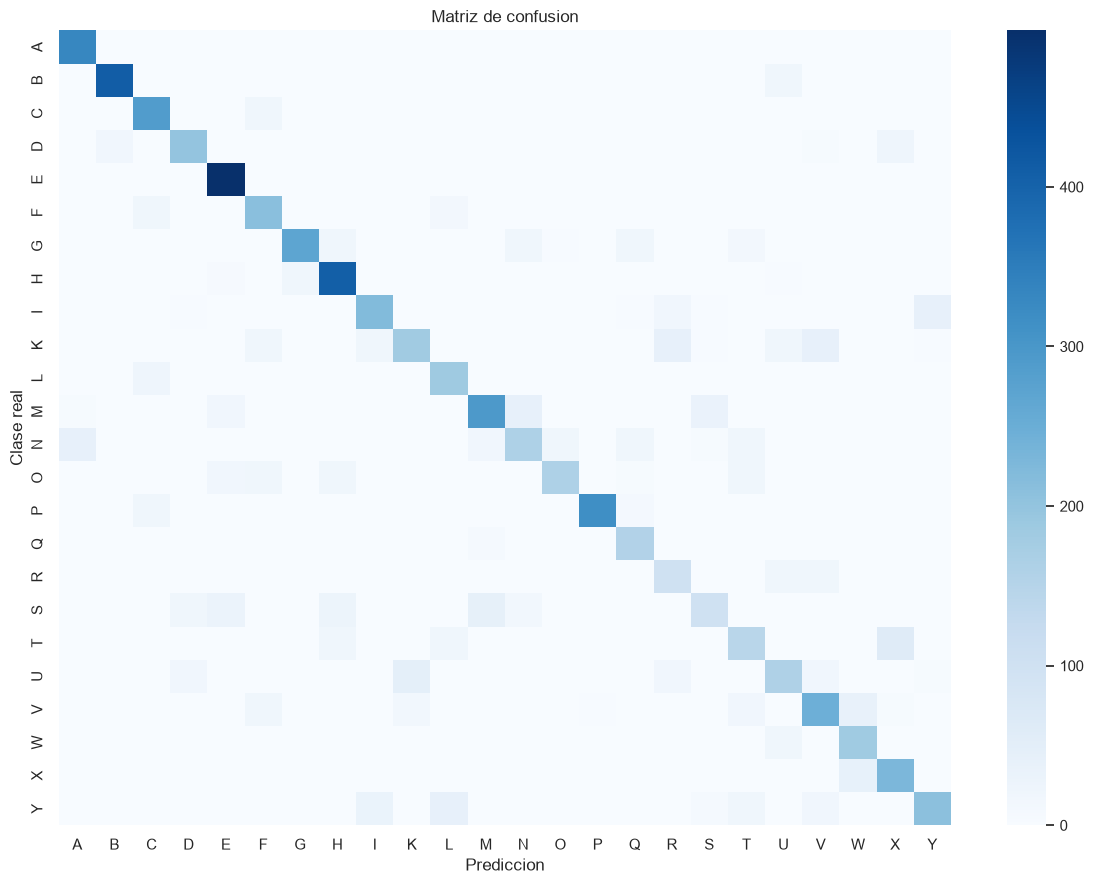

In [15]:
fig = plot_confusion(y_test_idx, y_pred, index_to_label)
fig.savefig(PROJECT_ROOT / "images" / "jenaro_integracion_confusion_matrix.png", dpi=150)
plt.show()

## 8. Analisis de errores

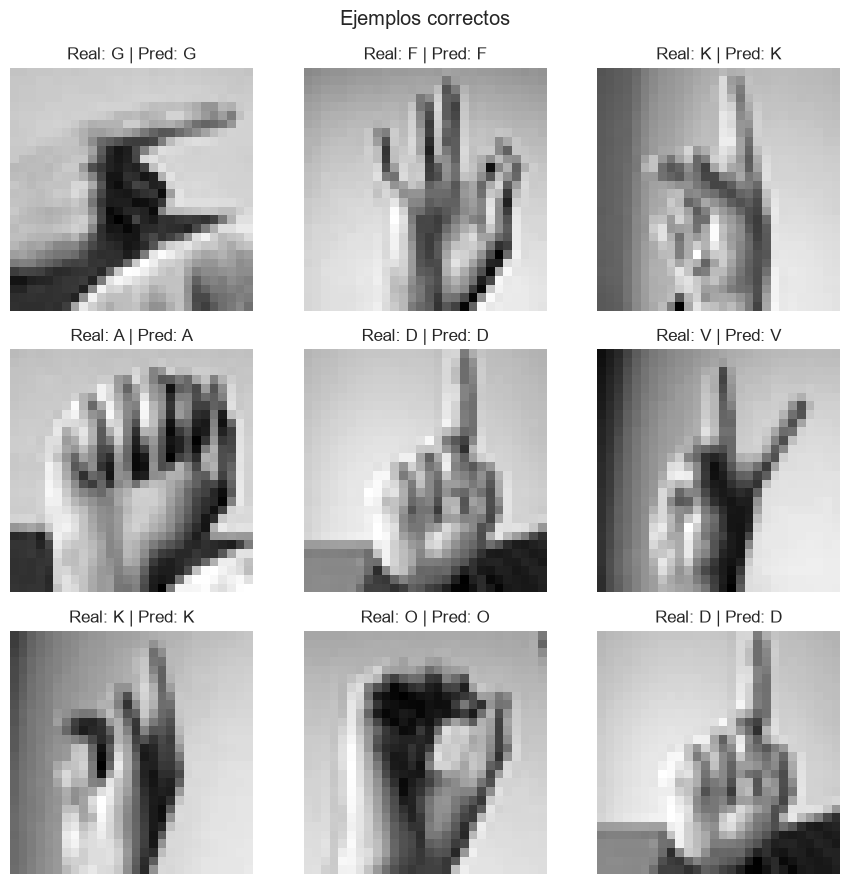

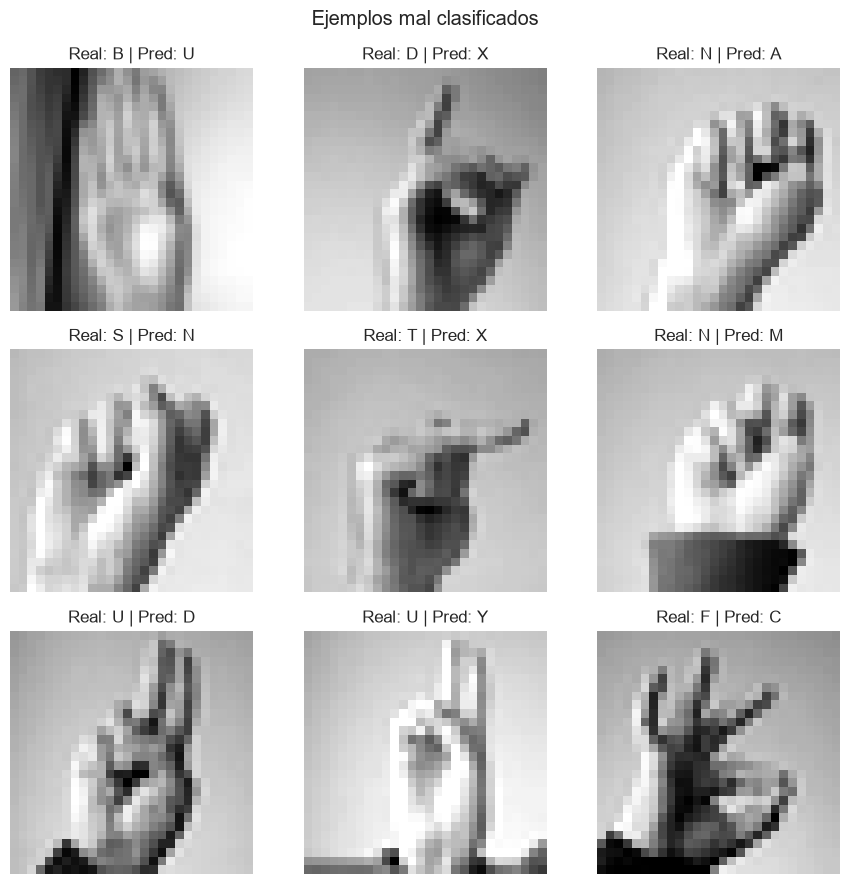

In [16]:
fig = plot_prediction_examples(X_test, y_test_idx, y_pred, index_to_label, correct=True, max_items=9)
fig.savefig(PROJECT_ROOT / "images" / "jenaro_integracion_correct_examples.png", dpi=150)
plt.show()

fig = plot_prediction_examples(X_test, y_test_idx, y_pred, index_to_label, correct=False, max_items=9)
fig.savefig(PROJECT_ROOT / "images" / "jenaro_integracion_incorrect_examples.png", dpi=150)
plt.show()

## 9. Guardado del modelo

In [17]:
print("Modelo ya guardado antes del test:", model_path.name)

Modelo ya guardado antes del test: jenaro_mlp.keras


## 10. Conclusiones del equipo — interpretación pendiente de Jason

El bloque anterior ya genera las métricas y los ejemplos con el modelo
seleccionado. Corresponde a Jason interpretar qué letras se confunden,
examinar las imágenes y redactar las conclusiones globales. Las decisiones
y conclusiones de entrenamiento de Jenaro están en la sección 6 y en
`reports/jenaro_modelo_entrenamiento.md`.

La documentación de la variante del equipo y la defensa conjunta deben
revisarse entre los integrantes; este notebook conserva las 24 clases y
el split original de Gonzalo.